In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [65]:
df = pd.read_csv("../csv/bigmart.csv")
df.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [66]:
# Aim of bigmart sales data is to predict the sales of a product based on the features provided in the dataset. The dataset contains information about various products sold in different outlets of BigMart, including product details, outlet details, and sales figures. By analyzing this data, we can build a predictive model to estimate future sales and make informed business decisions.

In [67]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [68]:
mean_weight = df['Item_Weight'].mean()
print(mean_weight)

12.857645184135976


In [69]:
df['Item_Weight'] = df['Item_Weight'].fillna(mean_weight)

In [70]:
mode_count = df['Outlet_Size'].mode()
mode_count[0]

'Medium'

In [71]:
df['Outlet_Size'] = df['Outlet_Size'].fillna(mode_count[0])

In [72]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [73]:
df = pd.get_dummies(df.drop(['Item_Identifier'], axis=1), dtype=int)

In [74]:
df.head(5)

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_Fat_Content_LF,Item_Fat_Content_Low Fat,Item_Fat_Content_Regular,Item_Fat_Content_low fat,Item_Fat_Content_reg,...,Outlet_Size_High,Outlet_Size_Medium,Outlet_Size_Small,Outlet_Location_Type_Tier 1,Outlet_Location_Type_Tier 2,Outlet_Location_Type_Tier 3,Outlet_Type_Grocery Store,Outlet_Type_Supermarket Type1,Outlet_Type_Supermarket Type2,Outlet_Type_Supermarket Type3
0,9.30,0.016047,249.8092,1999,3735.1380,0,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
1,5.92,0.019278,48.2692,2009,443.4228,0,0,1,0,0,...,0,1,0,0,0,1,0,0,1,0
2,17.50,0.016760,141.6180,1999,2097.2700,0,1,0,0,0,...,0,1,0,1,0,0,0,1,0,0
3,19.20,0.000000,182.0950,1998,732.3800,0,0,1,0,0,...,0,1,0,0,0,1,1,0,0,0
4,8.93,0.000000,53.8614,1987,994.7052,0,1,0,0,0,...,1,0,0,0,0,1,0,1,0,0


In [ ]:
# Now let's segregate features and target variable. The target variable is 'Item_Outlet_Sales', which we want to predict based on the other features in the dataset.

In [77]:
x = df.drop(['Item_Outlet_Sales'], axis=1)
y = df['Item_Outlet_Sales']
print(x.shape, y.shape)

(8523, 45) (8523,)


In [78]:
# We'll scale the features using StandardScaler to ensure that all features contribute equally to the distance calculations in KNN.

In [79]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [80]:
# Now, let's split the dataset into training and testing sets. We'll use 80% of the data for training and 20% for testing.

In [82]:
from sklearn.model_selection import train_test_split

In [84]:
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)

In [90]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_log_error

In [86]:
knn = KNeighborsRegressor(n_neighbors=5)

In [91]:
knn.fit(x_train, y_train)
test_pred = knn.predict(x_test)
rmlse = root_mean_squared_log_error(y_test, test_pred)
print(f"Root Mean Squared Log Error for KNN Regression: {rmlse}")

Root Mean Squared Log Error for KNN Regression: 0.6702228728767514


In [92]:
# This was okk for neighbours=5. In order to find the best value of k, we'll use the elbow method

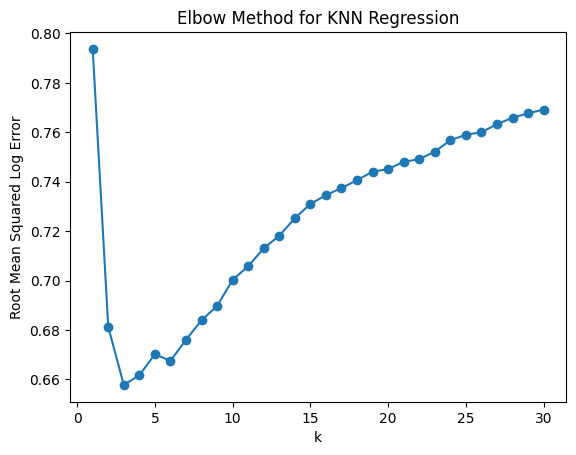

In [93]:
# Elbow method to find the best k value.
k_values = range(1, 31)
rmlse_values = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(x_train, y_train)
    test_pred = knn.predict(x_test)
    rmlse = root_mean_squared_log_error(y_test, test_pred)
    rmlse_values.append(rmlse)

plt.plot(k_values, rmlse_values, marker='o')
plt.xlabel('k')
plt.ylabel('Root Mean Squared Log Error')
plt.title('Elbow Method for KNN Regression')
plt.show()

In [94]:
# From the plot, we can see the minimum error value comes when k=3. Hence, we can use this value and check!

In [95]:
knn = KNeighborsRegressor(n_neighbors=3)
knn.fit(x_train, y_train)
test_pred = knn.predict(x_test)
rmlse = root_mean_squared_log_error(y_test, test_pred)
print(f"Root Mean Squared Log Error for KNN Regression with k=3: {rmlse}")

Root Mean Squared Log Error for KNN Regression with k=3: 0.6577861630504519


In [98]:
# THe train and test rmsle values are very close to each other, which indicates that the model is performing well and is not overfitting or underfitting. This suggests that the KNN regression model with k=3 is a good fit for this dataset.